# Deliverable 3: Flow-chamber model + validation (Checkpoint A)
**Lead:** Partner A (B runs the blind check) · **Shared files:** `ris/chlorine_backbone.py`, `ris/cipro_model.py`, `ris/flow_reactor.py`

**Part A: does the chemistry match a real experiment?** Compare the model with Dodd et al. 2005 Figure 5a: N-chloro-cipro decay in **real Atlanta wastewater and drinking water**. No numbers are fitted; every constant comes from Dodd's clean-water measurements.

**Part B: is the flow code right?** Three checks against textbook answers.

**Part C: tracer-test fitting:** the code that turns November's dye readings into N (number of tanks).

**Part D: chemistry in flow:** how mixing in the chamber changes what leaves.

In [1]:
# Load tools + the model code from this repo (run from the repo root or notebooks/)
import sys, pathlib
root = pathlib.Path.cwd()
if not (root / "ris").exists():
    root = root.parent
sys.path.insert(0, str(root))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from ris import chlorine_backbone as cb
from ris import cipro_model as cm
from ris import flow_reactor as fr
print("Loaded.")

Loaded.


## Part A · Validation against Dodd 2005 Figure 5a
**Conditions (Fig. 5 caption, Table 2):** 25 °C; cipro 1.5 × 10⁻⁶ M; free chlorine 1.6 × 10⁻⁴ M in Atlanta wastewater (pH 7.3, DOC 14 mg C/L) or 2.8 × 10⁻⁵ M in Atlanta drinking water (pH 6.6). Samples quenched with **thiosulfate**, so "measured" = cipro + N-chloro-cipro.

⚠️ **The data below were read off the figure by Claude from pixel positions (± ~0.02).** Before the poster, re-digitize Figure 5a yourself with WebPlotDigitizer (page 7074 of the PDF), paste the values here, and save them in `data/published/dodd2005_fig5a.csv` (Part A reads that file).

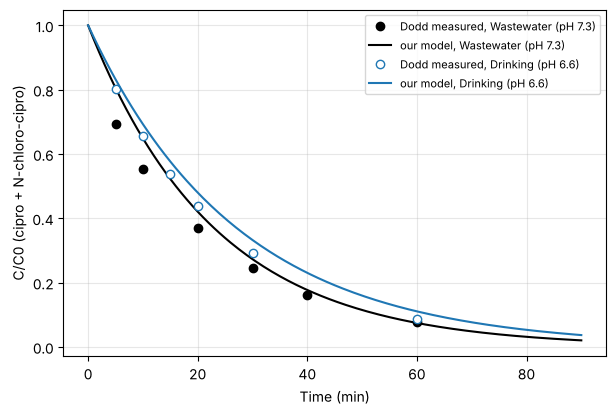

,water,RMSE (C/C0),mean error %,worst point %
0,Wastewater (pH 7.3),0.065,13.7,17.5
1,Drinking (pH 6.6),0.036,8.1,14.2


In [2]:
# Dodd 2005 Fig. 5a, read from data/published/dodd2005_fig5a.csv (PIXEL-ESTIMATED until re-digitized)
df = pd.read_csv(root / "data/published/dodd2005_fig5a.csv")
dodd = {}
for (water, pH, FAC), g in df.groupby(["water", "pH", "FAC_M"], sort=False):
    dodd[f"{water.capitalize()} (pH {pH})"] = dict(pH=pH, FAC_M=FAC, t=list(g.time_min), C=list(g.C_over_C0))
C0_M = 1.5e-6

def predict_thiosulfate_measured(pH, FAC_M, t_min):
    y0 = [FAC_M, 0, 0, 0, C0_M, 0, 0, 0]
    t_eval = np.array(t_min, float) * 60
    s = solve_ivp(cm.rates, [0, t_eval.max()], y0, args=(pH,), t_eval=t_eval,
                  method="LSODA", rtol=1e-9, atol=1e-18)
    return (s.y[4] + s.y[5]) / C0_M          # cipro + N-chloro-cipro, as thiosulfate would read it

plt.figure(figsize=(7, 4.5)); tt = np.linspace(0, 90, 181)
summary = []
for (name, d), col in zip(dodd.items(), ["k", "tab:blue"]):
    pred = predict_thiosulfate_measured(d["pH"], d["FAC_M"], d["t"])
    err = pred - np.array(d["C"])
    rel = [abs(e) / c for e, c in zip(err, d["C"]) if c > 0.1]     # skip tiny values (% blows up)
    summary.append([name, round(np.sqrt(np.mean(err**2)), 3), round(100*np.mean(rel), 1), round(100*max(rel), 1)])
    plt.plot(d["t"], d["C"], "o", color=col, mfc="white" if "Drinking" in name else col, label=f"Dodd measured, {name}")
    plt.plot(tt, predict_thiosulfate_measured(d["pH"], d["FAC_M"], tt), "-", color=col, label=f"our model, {name}")
plt.xlabel("Time (min)"); plt.ylabel("C/C0 (cipro + N-chloro-cipro)"); plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.show()
pd.DataFrame(summary, columns=["water", "RMSE (C/C0)", "mean error %", "worst point %"])

In [3]:
# Checkpoint A verdict (rule: mean error within ~20% on points with C/C0 > 0.1)
ok = all(row[2] <= 20 for row in summary)
print("CHECKPOINT A:", "PASS" if ok else "FAIL", "(pixel-estimated data; confirm after WebPlotDigitizer)")

# Independent check from a different lab: Jasper et al. 2016 measured the breakdown at pH 8.7
jasper = 5.6e-4
print(f"\nIndependent check, pH 8.7: model {cm.k_frag(8.7):.2e} s^-1 vs Jasper 2016 {jasper:.1e} s^-1 "
      f"({100*(cm.k_frag(8.7)/jasper - 1):+.0f}%)")

CHECKPOINT A: PASS (pixel-estimated data; confirm after WebPlotDigitizer)

Independent check, pH 8.7: model 7.58e-04 s^-1 vs Jasper 2016 5.6e-04 s^-1 (+35%)


**How to describe this honestly**
- Figure 5a is Dodd's *own* real-water check of his clean-water constants, so matching it shows our code reproduces his chemistry correctly. It is not a fully independent test.
- The independent check (Jasper 2016, different lab) differs by about **35%** at pH 8.7. Report it as the real uncertainty in the breakdown speed. It's a reason to **measure the breakdown speed in your own reactor**, not a failure.
- Wastewater decays faster than the model in the first 10 minutes (about 15–18% off). Possible reasons: pH not perfectly constant, or matrix effects. Worth one sentence on the poster.
- When Kennedy Neth 2019 arrives, add it as a second independent dataset here.

## Part B · Flow-code checks (textbook answers)
1. **Dye pulse, no reaction:** simulated outlet must match the exact tanks-in-series formula.
2. **1 tank, simple reaction (rate k):** outlet must equal 1/(1 + kτ).
3. **Many tanks:** outlet must approach e^(−kτ), the ideal-pipe answer.
4. **Full chemistry, many tanks:** must match the beaker model at the same time (a perfect pipe is a moving beaker).

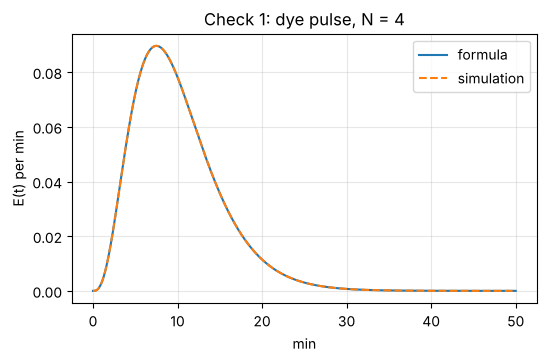

Check 1  pulse: max error 7.5e-08% of peak
Check 2  N=1:  0.5000  vs 1/(1+kτ) = 0.5000
Check 3  N=50: 0.3715  vs e^-kτ = 0.3679  (exact N=50 answer 0.3715)
Check 4  cipro_thiosulfate_ugL: flow N=100 268.6 vs beaker 266.2 µg/L
All flow checks passed.


In [4]:
tau, N = 600.0, 4                                   # 10-minute chamber, 4 tanks
t = np.linspace(0, 3000, 601)
E_sim, E_exact = fr.simulate_pulse(tau, N, t), fr.rtd_tanks(t, tau, N)
err1 = np.abs(E_sim - E_exact).max() / E_exact.max()
plt.figure(figsize=(6, 3.5)); plt.plot(t/60, E_exact*60, label="formula"); plt.plot(t/60, E_sim*60, "--", label="simulation")
plt.xlabel("min"); plt.ylabel("E(t) per min"); plt.title("Check 1: dye pulse, N = 4"); plt.legend(); plt.grid(alpha=0.3); plt.show()

k = 1 / tau                                          # chosen so kτ = 1
out1  = fr.steady_tanks(lambda y: [-k * y[0]], [1.0], tau, 1)[-1][0]
out50 = fr.steady_tanks(lambda y: [-k * y[0]], [1.0], tau, 50)[-1][0]

batch, _ = cm.run_batch(contact_min=30)
flow100, _ = fr.run_flow(N=100, contact_min=30)
key = "cipro_thiosulfate_ugL"

print(f"Check 1  pulse: max error {100*err1:.1e}% of peak")
print(f"Check 2  N=1:  {out1:.4f}  vs 1/(1+kτ) = {1/2:.4f}")
print(f"Check 3  N=50: {out50:.4f}  vs e^-kτ = {np.exp(-1):.4f}  (exact N=50 answer {(1+1/50)**-50:.4f})")
print(f"Check 4  {key}: flow N=100 {flow100[key]:.1f} vs beaker {batch[key]:.1f} µg/L")
assert err1 < 1e-4 and abs(out1 - 0.5) < 1e-6 and abs(out50 - (1+1/50)**-50) < 1e-4
assert abs(flow100[key] - batch[key]) / batch[key] < 0.02
print("All flow checks passed.")

## Part C · Fitting the tracer test (November)
In November you'll inject dye and record its color at the outlet over time. This finds **N** (how mixed the chamber is) and **τ** (average time). Demo on fake data with a known answer (N = 4, τ = 10 min), with 3% noise added:

Recovered N = 3.99 (true 4), tau = 9.98 min (true 10)


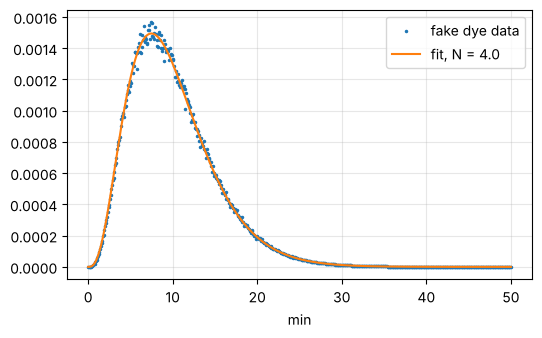

In [5]:
rng = np.random.default_rng(0)
fake = fr.rtd_tanks(t, 600, 4) * (1 + 0.03 * rng.standard_normal(t.size))
N_fit, tau_fit, curve = fr.fit_tanks(t, fake)
print(f"Recovered N = {N_fit:.2f} (true 4), tau = {tau_fit/60:.2f} min (true 10)")
plt.figure(figsize=(6, 3.5)); plt.plot(t/60, fake, ".", ms=3, label="fake dye data"); plt.plot(t/60, curve, label=f"fit, N = {N_fit:.1f}")
plt.xlabel("min"); plt.legend(); plt.grid(alpha=0.3); plt.show()

# November: put your CSV (columns: time_s, signal) in data/lab and run:
# df = pd.read_csv(root / 'data/lab/tracer_run1.csv')
# N_fit, tau_fit, _ = fr.fit_tanks(df.time_s, df.signal)

## Part D · Chemistry in the flow chamber
Same 30-minute average contact time, different amounts of mixing. Fewer tanks = more mixing = some water leaves early, some late. N = 5 is a placeholder until the tracer test.

In [6]:
rows = []
for N in [1, 2, 5, 20, 100]:
    r, _ = fr.run_flow(N=N, contact_min=30)
    rows.append([N, r["FC_end_mgL"], r["CT"], r["cipro_thiosulfate_ugL"], r["NCL_out_ugL"], r["P1_out_ugL"]])
r, _ = cm.run_batch(contact_min=30)
rows.append(["beaker", r["FC_end_mgL"], r["CT"], r["cipro_thiosulfate_ugL"], r["NCL_out_ugL"], r["P1_out_ugL"]])
pd.DataFrame(rows, columns=["N tanks", "free Cl out (mg/L)", "CT (mg·min/L)", "thiosulfate 'cipro' (µg/L)",
                            "N-chloro-cipro leaving (µg/L)", "P1 leaving (µg/L)"]).round(1)

,N tanks,free Cl out (mg/L),CT (mg·min/L),thiosulfate 'cipro' (µg/L),N-chloro-cipro leaving (µg/L),P1 leaving (µg/L)
0,1,3.5,104.6,430.4,345.2,440.8
1,2,3.4,111.6,362.2,290.5,485.3
2,5,3.3,116.4,309.1,247.9,522.7
3,20,3.3,119.1,277.7,222.7,546.2
4,100,3.3,119.8,268.6,215.4,553.1
5,beaker,3.3,120.0,266.2,213.6,554.9


**What this shows:** a more mixed chamber (small N) lets more N-chloro-cipro leave intact, because some water exits early. That's the amount that could turn back into cipro at the bisulfite step. So **how well the plant's contact basin approaches plug flow** affects Gap 2.

## Remaining for D3
- [ ] Re-digitize Dodd Fig. 5a with WebPlotDigitizer; save CSV; re-run Part A
- [ ] Add Kennedy Neth 2019 as a second dataset when the PDF arrives
- [ ] Partner B: mini blind check: predict one condition before looking at its data
- [ ] November: replace N = 5 with the tracer-test fit